# 🧠 5.1 MLP Classification Model & Hyperparameter Tuning

Este notebook entrena un clasificador basado en **Redes Neuronales Perceptrón Multicapa (MLP)** para la clasificación binaria sobre los embeddings generados por ProtFlash. A diferencia de una CNN, el MLP procesa los embeddings de forma global, agregando la información de la secuencia mediante *mean pooling* y combinándola con el embedding global.

---

## 📋 Descripción general

El modelo recibe tres entradas:
- `X`: embeddings por residuo, con forma `(B, L, 768)`.
- `G`: embedding global/contextual de la secuencia, con forma `(B, 768)`.
- `M`: máscara binaria, con forma `(B, L)`, usada para ignorar posiciones de padding.

La arquitectura `MeanMLPClassifier`:
1. Agrega los embeddings por residuo `X` mediante `MeanPooler`, respetando la máscara `M`.
2. Concatena el embedding agregado `E` con el embedding global `G`.
3. Procesa la representación combinada a través de capas `Linear`, `BatchNorm1d`, activación `GELU` y `Dropout`.
4. Finaliza con una capa lineal que produce los logits para la clasificación binaria.

---

## 🛠️ Funcionalidades principales

1. **Arquitectura del modelo**
   - Red MLP flexible con capas `Linear`, `BatchNorm1d`, `GELU` y `Dropout`.
   - Agregación de la secuencia mediante *mean pooling* con máscara.
   - Combinación con el embedding global para la clasificación.

2. **Entrenamiento y optimización**
   - Optimizador `AdamW` con *weight decay*.
   - Función de pérdida `FocalLoss` (basada en `binary_cross_entropy_with_logits`) para manejar el desbalance de clases.
   - `ReduceLROnPlateau` para ajustar la tasa de aprendizaje.
   - *Early stopping* basado en la pérdida de validación.

3. **Búsqueda de hiperparámetros**
   - Evaluación de tres configuraciones: `MLP_Small`, `MLP_Medium` y `MLP_Large`.
   - Variación del número de neuronas por capa oculta y del *dropout*.

4. **Monitoreo y registro**
   - Registro por época de pérdida de entrenamiento/validación, accuracy, MCC y ROC-AUC.
   - Guardado automático del mejor modelo según la menor pérdida de validación.
   - Exportación del historial de entrenamiento en CSV y de las métricas de validación en JSON.

## 📦 Importación de dependencias

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de rutas e hiperparámetros MLP

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/new-final-dataset")
OUT_DIR = Path("/kaggle/working/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT = DATA_DIR / "train_dataset.pt"
VAL_PT   = DATA_DIR / "val_dataset.pt"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 128
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
INPUT_DIM   = 768      # Dimensión de los embeddings

# ========== ARCHITECTURES ==========
ARCHITECTURES = [
    {
        "name": "MLP_Small",
        "hidden_dims": [256, 128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "MLP_Medium",
        "hidden_dims": [512, 256, 128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "MLP_Large",
        "hidden_dims": [1024, 512, 256, 128],
        "dropout": 0.4,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

print(f"INPUT_DIM: {INPUT_DIM}")
print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: layers={cfg['hidden_dims']}, dropout={cfg['dropout']}")

INPUT_DIM: 768
Architectures to compare: 3
  - MLP_Small: layers=[256, 128], dropout=0.3
  - MLP_Medium: layers=[512, 256, 128], dropout=0.3
  - MLP_Large: layers=[1024, 512, 256, 128], dropout=0.4


## 🖥️ Semilla para reproducibilidad y detección de dispositivo

In [3]:
def seed_everything(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {DEVICE}")

🚀 Device: cuda


## 📂 Definición de la clase `AMPDataset`

In [4]:
class AMPDataset(Dataset):
    def __init__(self, X, G, M, sequences, labels):
        self.X = torch.from_numpy(X).float() if isinstance(X, np.ndarray) else X
        self.G = torch.from_numpy(G).float() if isinstance(G, np.ndarray) else G
        self.M = torch.from_numpy(M).float() if isinstance(M, np.ndarray) else M
        self.sequences = sequences
        self.y = torch.from_numpy(labels).float().unsqueeze(1) if isinstance(labels, np.ndarray) else labels
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return {"X": self.X[idx], "G": self.G[idx], "M": self.M[idx], "seq": self.sequences[idx], "y": self.y[idx]}

## 💾 Función de carga de datasets pre-serializados

In [5]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de entrenamiento y validación

In [6]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13766 muestras
   val_ds  : 4128 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   y: str = 'seq'


## 🤝 Función de colación (`collate_fn`)

In [7]:
def collate_fn(batch):
    if isinstance(batch[0], dict):
        embeddings = torch.stack([item['X'] for item in batch], dim=0)
        globals_emb = torch.stack([item['G'] for item in batch], dim=0) 
        masks       = torch.stack([item['M'] for item in batch], dim=0)
        labels      = torch.stack([item['y'] for item in batch], dim=0)
    else:
        raise TypeError(f"Batch fallido")
    return embeddings, globals_emb, masks, labels

## 🚚 Creación de DataLoaders

In [8]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✅ Batches: train={len(train_loader)}, val={len(val_loader)}")

X_b, G_b, M_b, y_b = next(iter(train_loader))
print(f"   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)}")


✅ Batches: train=108, val=33
   ✅ X_b: (128, 100, 768) | G_b: (128, 768)


## 🔑 Mecanismo `MeanPooler`

In [9]:
class MeanPooler(nn.Module):
    """
    Mean pooling simple con máscara.
    
    Input:
      - X: (B, L, D) embeddings por residuo
      - M: (B, L) máscara binaria (1 = residuo válido, 0 = padding)
    
    Output:
      - E: (B, D) embedding agregado por secuencia
    """
    def __init__(self, input_dim: int):
        super().__init__()

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        mask = M.unsqueeze(-1)                        # (B, L, 1)
        summed = (X * mask).sum(dim=1)               # (B, D)
        counts = mask.sum(dim=1).clamp(min=1e-8)     # (B, 1)
        return summed / counts                        # (B, D)

## 🏗️ Arquitectura `MLPClassifier` y Verificación

In [10]:
class MeanMLPClassifier(nn.Module):

    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float = 0.3):
        super().__init__()

        self.pooler = MeanPooler(input_dim=input_dim)

        layers = []
        in_features = input_dim * 2

        for out_features in hidden_dims:
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            in_features = out_features

        self.mlp_body = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_features, 1)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        E = self.pooler(X, M)            # (B, D)
        combined = torch.cat([E, G], dim=1)  # (B, 2D)
        x = self.mlp_body(combined)
        return self.classifier(x)


def build_mean_mlp_model(config: Dict, input_dim: int) -> nn.Module:
    return MeanMLPClassifier(input_dim, config["hidden_dims"], config["dropout"])

## 📐 Helper: `sigmoid_np`

In [11]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [12]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    """Return (probabilities, true_labels) from a DataLoader."""
    model.eval()
    logits_list, y_list = [], []
    
    for batch in loader:
        # Desempaquetar los 4 tensores (X, G, M, y)
        Xb, Gb, Mb, yb = [b.to(device) for b in batch]
        
        # Pasamos los 3 tensores de entrada
        logits = model(Xb, Gb, Mb)
        
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
        
    logits_all = np.concatenate(logits_list)
    y_all = np.concatenate(y_list)
    return sigmoid_np(logits_all), y_all

## 📏 Cálculo de Métricas de Clasificación

In [13]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [15]:
def train_model(config, input_dim, train_loader, val_loader, device,
                max_epochs=MAX_EPOCHS, patience=PATIENCE):

    seed_everything(SEED)

    model = build_mean_mlp_model(config, input_dim).to(device)

    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": [], "val_roc_auc": []}

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, max_epochs + 1):

        # ================= TRAIN =================
        model.train()

        train_loss = 0.0
        n = 0

        for Xb, Gb, Mb, yb in train_loader:

            Xb = Xb.to(device)
            Gb = Gb.to(device)
            Mb = Mb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(Xb, Gb, Mb)

            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)

        train_loss /= n

        # ================= VALIDATION =================
        model.eval()

        val_loss = 0.0
        n = 0

        with torch.no_grad():

            for Xb, Gb, Mb, yb in val_loader:

                Xb = Xb.to(device)
                Gb = Gb.to(device)
                Mb = Mb.to(device)
                yb = yb.to(device)

                logits = model(Xb, Gb, Mb)

                loss = criterion(logits, yb)

                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)

        val_loss /= n

        scheduler.step(val_loss)

        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); 
        history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])
        history["val_roc_auc"].append(v_met["roc_auc"])

        if val_loss < best_val_loss - MIN_DELTA:

            best_val_loss = val_loss
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            best_epoch = epoch
            no_improve = 0

        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
    }

## 🔬 Ejecución Secuencial de Arquitecturas

In [16]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    n_params = sum(p.numel() for p in res["model"].parameters())

    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({
        "model_name": config["name"],
        "state_dict": res["model"].state_dict(),
        "config": config,
        "input_dim": INPUT_DIM
    }, ckpt_path)

    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "model": res["model"],
        "config": config,
        "history": res["history"],
    })

    
    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_roc_auc={v_metrics.get('roc_auc', 0.0):.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)


--- Entrenando MLP_Small ---
E01 | TL: 0.0616 | VL: 0.0532 | Val MCC: 0.7703 | B_ep: 1
E02 | TL: 0.0506 | VL: 0.0543 | Val MCC: 0.7835 | B_ep: 1
E03 | TL: 0.0483 | VL: 0.0511 | Val MCC: 0.7926 | B_ep: 3
E04 | TL: 0.0443 | VL: 0.0512 | Val MCC: 0.7842 | B_ep: 3
E05 | TL: 0.0425 | VL: 0.0505 | Val MCC: 0.7960 | B_ep: 5
E06 | TL: 0.0400 | VL: 0.0522 | Val MCC: 0.7995 | B_ep: 5
E07 | TL: 0.0381 | VL: 0.0496 | Val MCC: 0.8058 | B_ep: 7
E08 | TL: 0.0372 | VL: 0.0515 | Val MCC: 0.7992 | B_ep: 7
E09 | TL: 0.0346 | VL: 0.0519 | Val MCC: 0.7935 | B_ep: 7
E10 | TL: 0.0327 | VL: 0.0528 | Val MCC: 0.8005 | B_ep: 7
E11 | TL: 0.0321 | VL: 0.0567 | Val MCC: 0.7899 | B_ep: 7
E12 | TL: 0.0305 | VL: 0.0529 | Val MCC: 0.8092 | B_ep: 7
E13 | TL: 0.0294 | VL: 0.0547 | Val MCC: 0.8103 | B_ep: 7
E14 | TL: 0.0252 | VL: 0.0584 | Val MCC: 0.8020 | B_ep: 7
E15 | TL: 0.0244 | VL: 0.0597 | Val MCC: 0.8063 | B_ep: 7
E16 | TL: 0.0213 | VL: 0.0611 | Val MCC: 0.8116 | B_ep: 7
E17 | TL: 0.0211 | VL: 0.0593 | Val MCC: 0

## 📊 Tabla Resumen y Ranking de Modelos

In [17]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("ARCHITECTURE COMPARISON (sorted by Val MCC)")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)

summary_df.to_csv(OUT_DIR / "mlp_architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


ARCHITECTURE COMPARISON (sorted by Val MCC)
        Model   Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC
0   MLP_Small   427265           7  0.049557  0.901890  0.889856  0.805788     0.958447    0.964126
1   MLP_Large  2266881           4  0.049279  0.896318  0.883822  0.794260     0.955753    0.961676
2  MLP_Medium   953089           3  0.050772  0.891473  0.878722  0.784139     0.953045    0.959085

Saved

🏆 Best model: MLP_Small


## 📈 Visualización: Curvas de Entrenamiento Individuales

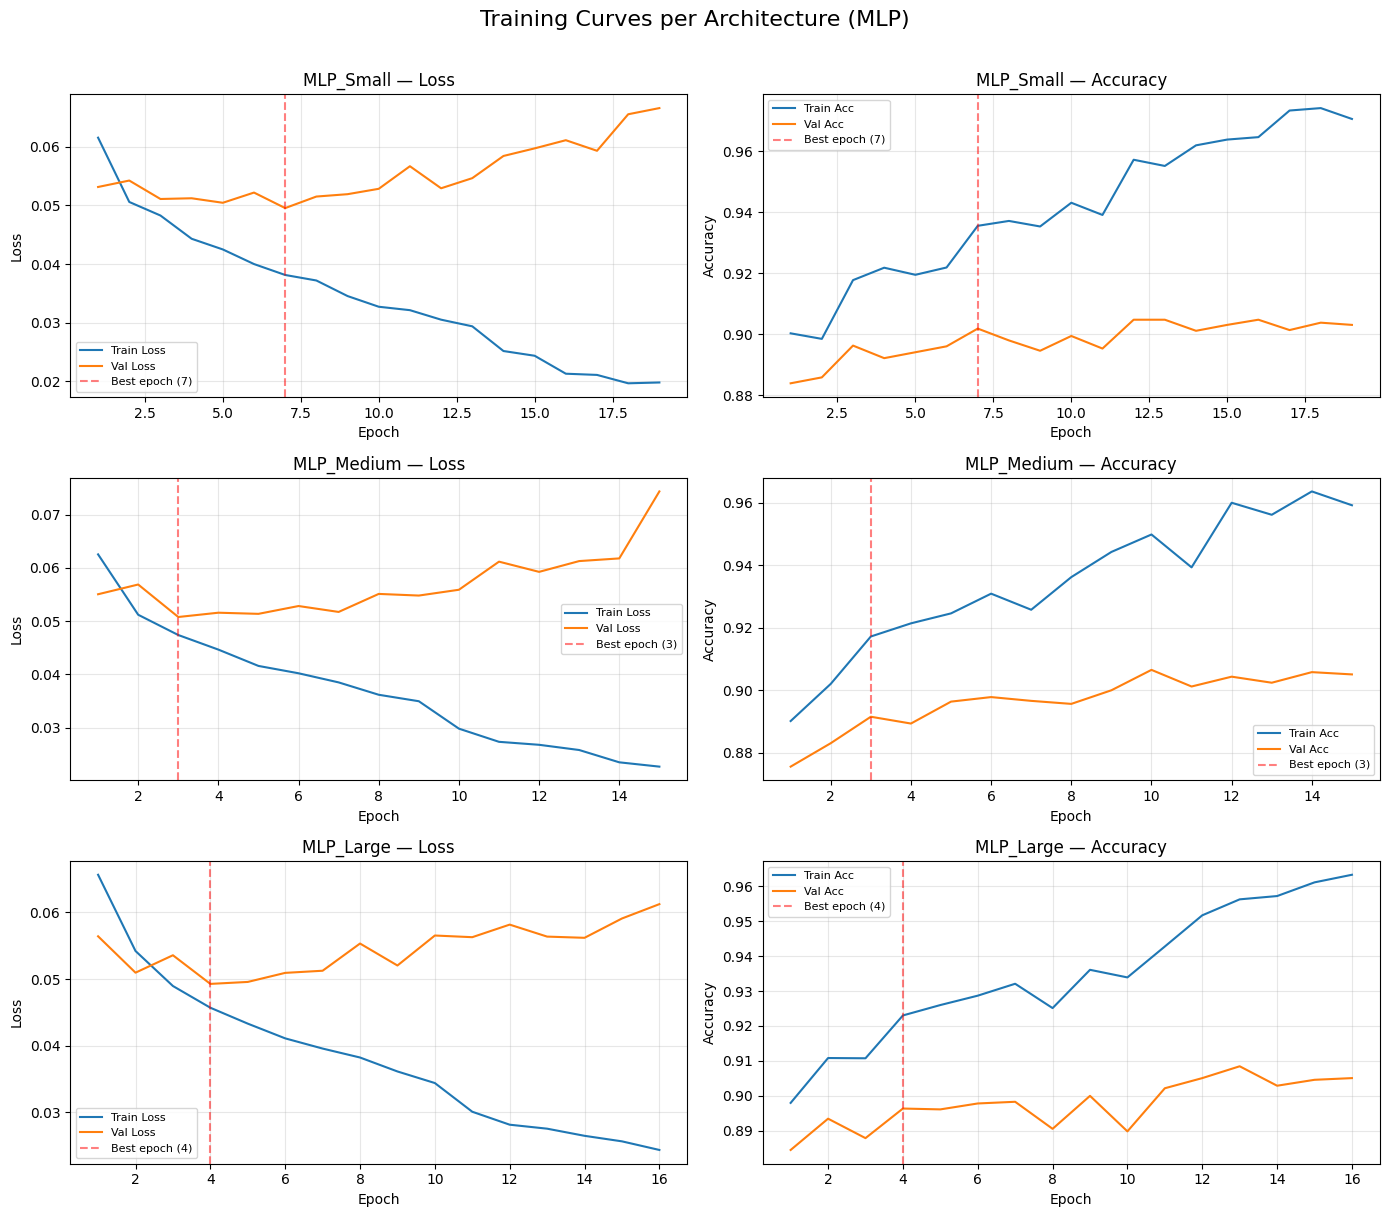

Saved: /kaggle/working/training_curves_individual.png


In [18]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (MLP)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Curvas comparativas conjuntas

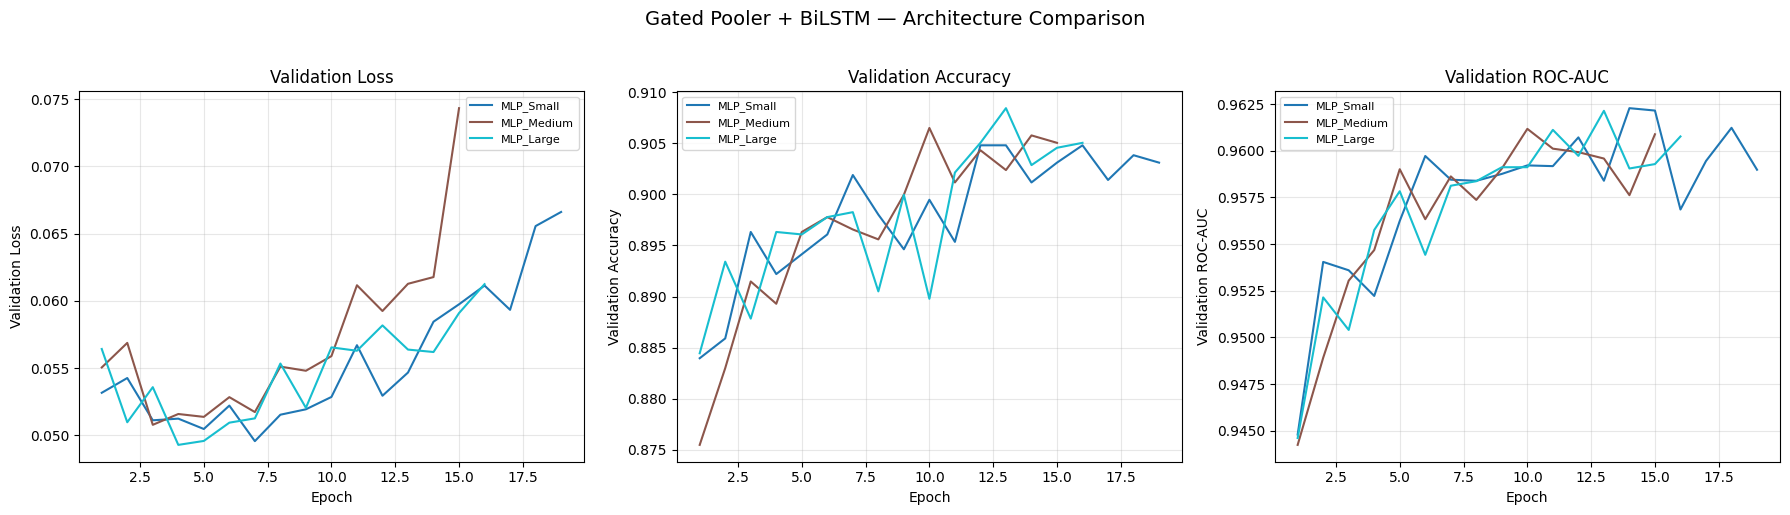

Saved: /kaggle/working/training_curves_comparison.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_roc_auc"], label=r["name"], color=colors[idx], linewidth=1.5)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Validation ROC-AUC"); axes[2].set_title("Validation ROC-AUC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler + BiLSTM — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

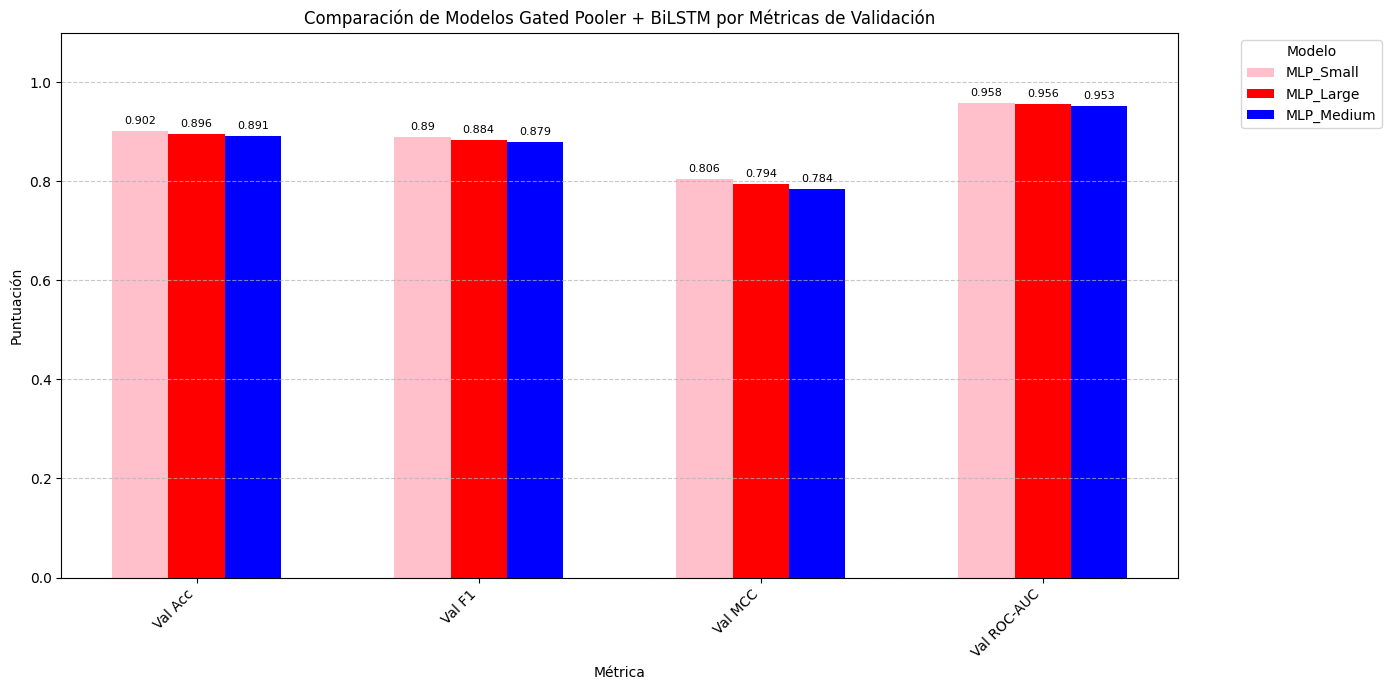

Saved: /kaggle/working/model_metrics_comparison_bar_chart.png


In [20]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['pink', 'red', 'blue', 'violet']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler + BiLSTM por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [21]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "mean_mlp_best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"\n🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")


🏆 Best model: MLP_Small
   Parameters: 427,265
   Best epoch: 7
   Val loss:   0.049557

Saved:
  Checkpoint:    /kaggle/working/mean_mlp_best_model_final.pth
  Training log:  /kaggle/working/best_model_training_log.csv
  Val metrics:   /kaggle/working/best_model_val_metrics.json


## 🏆 Conclusión: el mejor modelo

Tras completar el proceso de experimentación, se concluye que la configuración **MLP_Small** ofrece el mejor rendimiento entre las arquitecturas MLP evaluadas, según la métrica de validación **MCC**.

### Resultados destacados

| Métrica       | Valor  |
|---------------|--------|
| Mejor modelo  | MLP_Small |
| Parámetros    | 427,265 |
| Mejor época   | 7 |
| Val loss      | 0.0496 |
| Val Accuracy  | 0.9014 |
| Val F1        | 0.8906 |
| Val MCC       | 0.8035 |
| Val ROC-AUC   | 0.9606 |
| Val PR-AUC    | 0.9641 |

### Análisis

- **Capacidad de aprendizaje:** el modelo converge rápidamente gracias a la alta calidad de los embeddings de 768 dimensiones, alcanzando un buen rendimiento en pocas épocas.
- **Generalización:** con un *dropout* de 0.3 se logra una brecha mínima entre entrenamiento y validación, asegurando robustez ante secuencias nuevas.
- **Eficiencia:** a pesar de tener menos parámetros que las variantes `MLP_Medium` y `MLP_Large`, `MLP_Small` logra el mejor equilibrio entre rendimiento y costo computacional.

**Estado final:** el modelo ha sido exportado como `mean_mlp_best_model_final.pth`, quedando listo para su despliegue en producción o integración en herramientas de análisis bioinformático.